In [1]:
import sklearn
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_iris
#导入数据集
from sklearn.metrics import confusion_matrix
#导入输出混淆矩阵的包
from sklearn.metrics import ConfusionMatrixDisplay
#导入画混淆矩阵的包
from sklearn.metrics import RocCurveDisplay
#导入画ROC曲线的包
from sklearn import metrics
# 导入矩阵
import numpy as np

In [2]:
from sklearn.neighbors import KNeighborsClassifier
#导入knn模型

In [3]:
iris=datasets.load_iris()
# 加载鸢尾花数据集

In [4]:
x=iris.data
y=iris.target
Labels=iris.target
y = y==2#make binary
labels=iris.target_names

In [5]:
y

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [6]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3)

In [7]:
knn=KNeighborsClassifier()
knn.fit(x_train,y_train)

KNeighborsClassifier()

In [8]:
y_pre=knn.predict(x_test)
print(y_pre)
#预测值

[ True  True False False False False False False False False  True  True
 False False False  True False  True False False False  True  True False
 False False False False False False False  True False False False False
  True  True  True False False  True  True False False]


In [9]:
print(y_test)
#真实值

[ True  True False False False False False False False False  True  True
 False False False  True False  True False False False  True  True False
 False False False False False False False  True False False False False
  True  True  True False False  True False False False]


In [10]:
# 输出混淆矩阵
cm=confusion_matrix(y_true=y_test,y_pred=y_pre)
print(cm)

[[31  1]
 [ 0 13]]


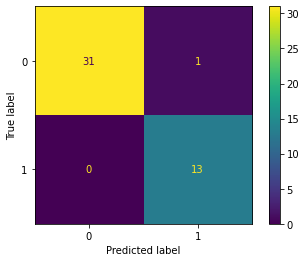

In [11]:
# 输出混淆矩阵图
disp=ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [12]:
# 对混淆矩阵归一化处理
cm1=confusion_matrix(y_true=y_test,y_pred=y_pre,normalize='true')
print(cm1)

[[0.96875 0.03125]
 [0.      1.     ]]


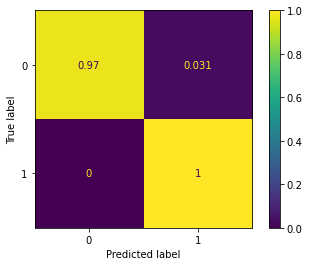

In [13]:
# 输出归一化后的混淆矩阵图
disp1=ConfusionMatrixDisplay(confusion_matrix=cm1)
disp1.plot()
plt.show()

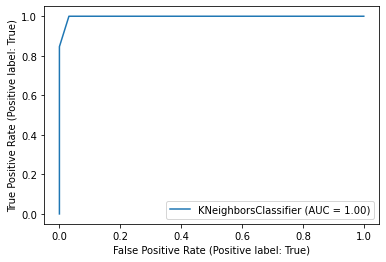

In [14]:
knn_disp=RocCurveDisplay.from_estimator(knn,x_test,y_test)
plt.show()

In [15]:
from sklearn import tree
# 导入决策树模型

In [16]:
dt=tree.DecisionTreeClassifier()
dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [17]:
y_pred=dt.predict(x_test)
print(y_pred)

[ True  True False False False False False False False False  True  True
 False False False  True False  True False False False  True  True False
 False False False False False False False  True False False False False
  True  True  True False False  True  True False False]


In [18]:
# 输出混淆矩阵
Cm=confusion_matrix(y_true=y_test,y_pred=y_pred)
print(Cm)

[[31  1]
 [ 0 13]]


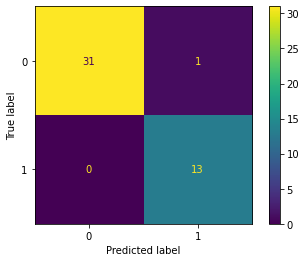

In [19]:
# 输出混淆矩阵图
Disp=ConfusionMatrixDisplay(confusion_matrix=Cm)
Disp.plot()
plt.show()

In [20]:
# 对混淆矩阵归一化处理
Cm1=confusion_matrix(y_true=y_test,y_pred=y_pre,normalize='true')
print(Cm1)

[[0.96875 0.03125]
 [0.      1.     ]]


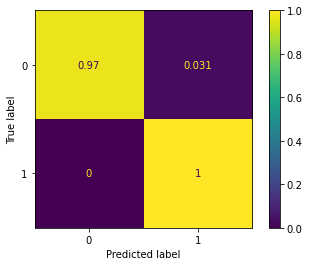

In [21]:
# 输出归一化后的混淆矩阵图
Disp1=ConfusionMatrixDisplay(confusion_matrix=Cm1)
Disp1.plot()
plt.show()

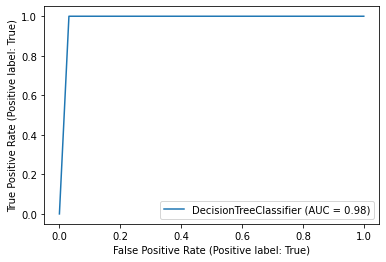

In [22]:
# 输出ROC曲线图
dt_disp=RocCurveDisplay.from_estimator(dt,x_test,y_test)
plt.show()

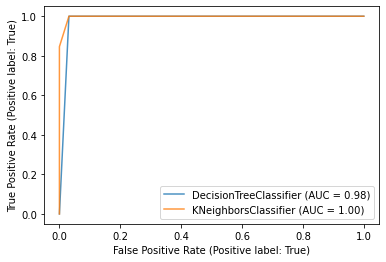

In [23]:
# 输出两个分类器对比的ROC曲线图
ax = plt.gca()
dt_disp = RocCurveDisplay.from_estimator(dt, x_test, y_test, ax=ax, alpha=0.8)
knn_disp.plot(ax=ax, alpha=0.8)

In [24]:
from time import time
from sklearn import metrics
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

In [25]:
data=iris.data

In [26]:
'''estimator = make_pipeline(StandardScaler(), kmeans).fit(data)
print(estimator)
print(estimator[-1].inertia_)
clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
        metrics.adjusted_mutual_info_score,
    ]
print(clustering_metrics)
print()
a=[m(labels, estimator[-1].labels_) for m in clustering_metrics]'''

'estimator = make_pipeline(StandardScaler(), kmeans).fit(data)\nprint(estimator)\nprint(estimator[-1].inertia_)\nclustering_metrics = [\n        metrics.homogeneity_score,\n        metrics.completeness_score,\n        metrics.v_measure_score,\n        metrics.adjusted_rand_score,\n        metrics.adjusted_mutual_info_score,\n    ]\nprint(clustering_metrics)\nprint()\na=[m(labels, estimator[-1].labels_) for m in clustering_metrics]'

In [27]:
def bench_k_means(kmeans, name, data, labels):
    t0 = time()
    estimator = make_pipeline(StandardScaler(), kmeans).fit(data)
    fit_time = time() - t0
    results = [name, fit_time, estimator[-1].inertia_]
    clustering_metrics = [
        metrics.homogeneity_score,
        metrics.completeness_score,
        metrics.v_measure_score,
        metrics.adjusted_rand_score,
        metrics.adjusted_mutual_info_score,
    ]
    results += [m(labels, estimator[-1].labels_) for m in clustering_metrics]
    results += [
        metrics.silhouette_score(
            data,
            estimator[-1].labels_,
            metric="euclidean",
            sample_size=300,
        )
    ]
    formatter_result = (
        "{:9s}\t{:.3f}s\t{:.0f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}\t{:.3f}"
    )
    print(formatter_result.format(*results))

In [28]:
(n_samples, n_features), n_digits = data.shape, np.unique(labels).size
print(data.shape)
print(n_samples)
print(n_features)
print(labels)

(150, 4)
150
4
['setosa' 'versicolor' 'virginica']


In [29]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print(82 * "_")
print("init\t\ttime\tinertia\thomo\tcompl\tv-meas\tARI\tAMI\tsilhouette")

kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="k-means++", data=data, labels=Labels)

kmeans = KMeans(init="random", n_clusters=n_digits, n_init=4, random_state=0)
bench_k_means(kmeans=kmeans, name="random", data=data, labels=Labels)

pca = PCA(n_components=n_digits).fit(data)
kmeans = KMeans(init=pca.components_, n_clusters=n_digits, n_init=1)
bench_k_means(kmeans=kmeans, name="PCA-based", data=data, labels=Labels)

print(82 * "_")

__________________________________________________________________________________
init		time	inertia	homo	compl	v-meas	ARI	AMI	silhouette
k-means++	0.119s	140	0.659	0.660	0.659	0.620	0.655	0.506
random   	0.014s	140	0.659	0.660	0.659	0.620	0.655	0.506
PCA-based	0.004s	191	0.535	0.657	0.590	0.433	0.584	0.519
__________________________________________________________________________________


C:\Users\mengyan-zhishang\anaconda3\envs\pytorch\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mengyan-zhishang\anaconda3\envs\pytorch\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Users\mengyan-zhishang\anaconda3\envs\pytorch\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


C:\Users\mengyan-zhishang\anaconda3\envs\pytorch\lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


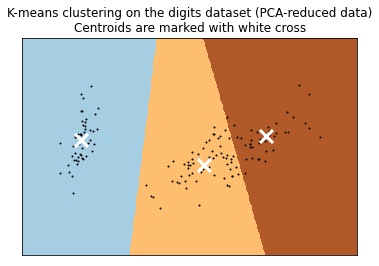

In [30]:
import matplotlib.pyplot as plt

reduced_data = PCA(n_components=2).fit_transform(data)
kmeans = KMeans(init="k-means++", n_clusters=n_digits, n_init=4)
kmeans.fit(reduced_data)

# Step size of the mesh. Decrease to increase the quality of the VQ.
h = 0.02  # point in the mesh [x_min, x_max]x[y_min, y_max].

# Plot the decision boundary. For that, we will assign a color to each
x_min, x_max = reduced_data[:, 0].min() - 1, reduced_data[:, 0].max() + 1
y_min, y_max = reduced_data[:, 1].min() - 1, reduced_data[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Obtain labels for each point in mesh. Use last trained model.
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])

# Put the result into a color plot
Z = Z.reshape(xx.shape)
plt.figure(1)
plt.clf()
plt.imshow(
    Z,
    interpolation="nearest",
    extent=(xx.min(), xx.max(), yy.min(), yy.max()),
    cmap=plt.cm.Paired,
    aspect="auto",
    origin="lower",
)

plt.plot(reduced_data[:, 0], reduced_data[:, 1], "k.", markersize=2)
# Plot the centroids as a white X
centroids = kmeans.cluster_centers_
plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="x",
    s=169,
    linewidths=3,
    color="w",
    zorder=10,
)
plt.title(
    "K-means clustering on the digits dataset (PCA-reduced data)\n"
    "Centroids are marked with white cross"
)
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xticks(())
plt.yticks(())
plt.show()
